# Apresentação do Eixo 1 
## Grupo:
- ### Leonardo D.
- ### João Pedro M.
- ### Thiago T.
- ### Victor B.
- ### Julio Cesar A. 

In [1]:

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from dython.nominal import associations

## **Verificações iniciais dos dados**

In [2]:
df = pd.read_csv("data/bmw.csv")
display(df)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


### **Renomeando colunas para facilitar o entendimento**

In [3]:
map = {
    'model': 'modelo',
    'year': 'ano',
    'price': 'preço',
    'transmission': 'transmissão',
    'mileage': 'quilometragem',
    'fuelType': 'tipo de combustivel',
    'tax': 'imposto',
    'mpg': 'economia', 
    'engineSize': 'cilindradas'
}

df.rename(columns=map, inplace=True)

# Corrige espaços errados na coluna do nome
df['modelo'] = df['modelo'].str.strip()

display(df)

,modelo,ano,preço,transmissão,quilometragem,tipo de combustivel,imposto,economia,cilindradas
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0
...,...,...,...,...,...,...,...,...,...
10776,X3,2016,19000,Automatic,40818,Diesel,150,54.3,2.0
10777,5 Series,2016,14600,Automatic,42947,Diesel,125,60.1,2.0
10778,3 Series,2017,13100,Manual,25468,Petrol,200,42.8,2.0
10779,1 Series,2014,9930,Automatic,45000,Diesel,30,64.2,2.0


### **Verificação de dados faltantes**

In [4]:
print(df.isnull().sum())

modelo                 0
ano                    0
preço                  0
transmissão            0
quilometragem          0
tipo de combustivel    0
imposto                0
economia               0
cilindradas            0
dtype: int64


### **Verificação dos modelos**

In [5]:
print(f"Modelos distintos nos dados: {df["modelo"].nunique()}")
print("\n----------------------------------------------------------------\n")
print(f"Quais são esses modelos: {df["modelo"].unique()}")
print("\n----------------------------------------------------------------\n")
print(f"Quantas vezes cada modelo aparece:\n{df["modelo"].value_counts()}")

Modelos distintos nos dados: 24

----------------------------------------------------------------

Quais são esses modelos: <StringArray>
['5 Series', '6 Series', '1 Series', '7 Series', '2 Series', '4 Series',
       'X3', '3 Series',       'X5',       'X4',       'i3',       'X1',
       'M4',       'X2',       'X6', '8 Series',       'Z4',       'X7',
       'M5',       'i8',       'M2',       'M3',       'M6',       'Z3']
Length: 24, dtype: str

----------------------------------------------------------------

Quantas vezes cada modelo aparece:
modelo
3 Series    2443
1 Series    1969
2 Series    1229
5 Series    1056
4 Series     995
X1           804
X3           551
X5           468
X2           288
X4           179
M4           125
6 Series     108
Z4           108
7 Series     106
X6           106
X7            55
i3            43
8 Series      39
M5            29
M3            27
M2            21
i8            17
M6             8
Z3             7
Name: count, dtype: int64


### Reparamos que nossos dados estão divididos entre **modelos e séries** (uma série agrupa vários modelos). Por isso, decidimos separar os dados em um **dataframe de modelos apenas** e outro **dataframe de séries apenas**.

In [6]:
# Define o critério de seleção
mask = df["modelo"].str.contains("Series", na=False)

# Separando quem atende ao critério
df_series = df[mask].copy()

# Separando quem não atende ao critério
df_models = df[~mask].copy()

# Verificação
print(f"Total original: {len(df)}")
print(f"Séries: {len(df_series)}")
print(f"Modelos: {len(df_models)}")

Total original: 10781
Séries: 7945
Modelos: 2836


### Agora, com dois dataframes distintos, podemos analisá-los separadamente

## **Plots e gráficos**

### **Matriz de correlação**
Este conjunto de dados possui alguns atributos categóricos (modelo, ano, transmissão e tipo de combustível). Por isso, nós usamos uma abordagem diferente: a função `df.corr()` do pandas usa a correlação de **Pearson** por padrão, que mede a relação entre variáveis numéricas. Se nós apenas fizessemos encoding nos atributos categóricos (ex: BMW X1 = 1, BMW X3 = 2), o Pearson tentaria achar uma relação matemática falsa, achando que o X3 "vale o dobro" do X1, o que não faz sentido.

Para contornar, usamos o pacote `dython`, que possui a **Razão de Correlação** (Correlation Ratio), ou seja, mede o quanto a dispersão de um dado numérico é explicada por categorias. Também possui Cramér's V (para categóricos x categóricos) e Pearson (numéricos x numéricos).

#### **Matriz de correlação dos modelos:**

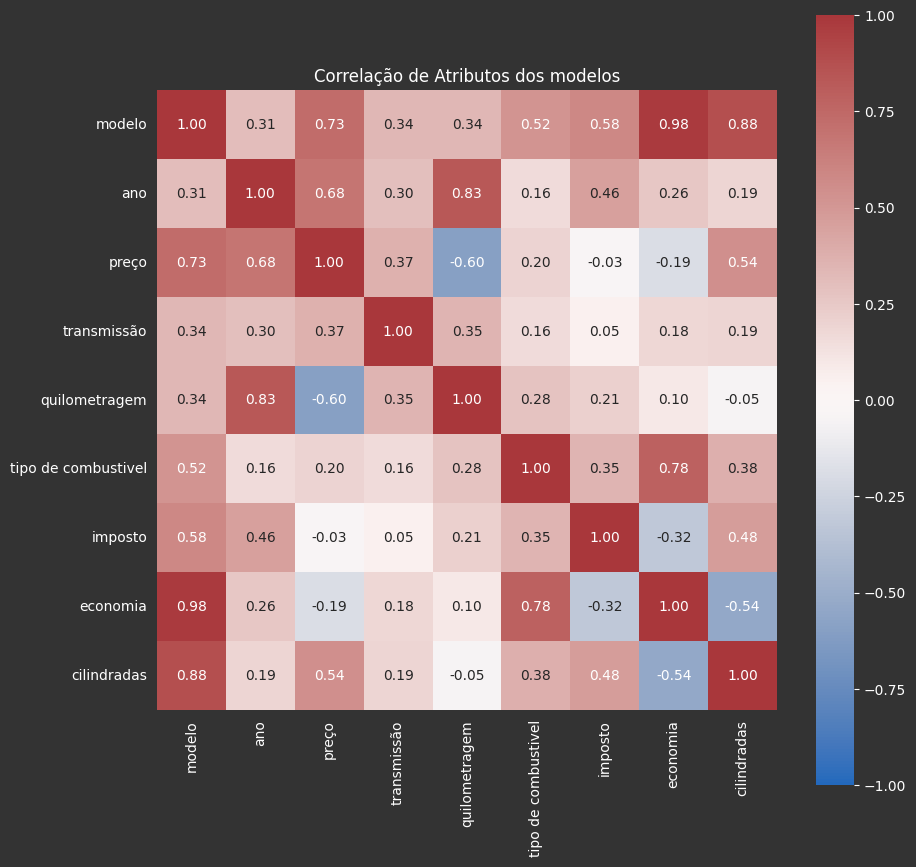

In [7]:
# Configurações visuais do Dark Mode
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#333333'
plt.rcParams['axes.facecolor'] = '#444444'

# Colunas categóricas
categorical_columns = ['modelo', 'ano', 'transmissão', 'tipo de combustivel']

# A função já calcula e plota automaticamente
result= associations(
    df_models,
    nominal_columns=categorical_columns,
    compute_only=False, # Gera o gráfico
    cmap='vlag',    # Mapa de cores 
    figsize=(10, 10), 
    title="Correlação de Atributos dos modelos"
)

# Também recuperamos os valores numéricos
corr_matrix = result['corr']

**Para interpretar estes resultados, vamos dividir em 5 categorias:**
- 0.00 a 0.19 - Muito Fraca	
- 0.20 a 0.39 - Fraca: Existe uma leve tendência, mas com muito ruído
- 0.40 a 0.59 - Moderada: Uma variável começa a explicar a outra
- 0.60 a 0.79 - Forte: Relação confiável
- 0.80 a 1.00 - Muito Forte: As vezes é a mesma informação mapeada de formas diferentes

In [8]:
# Transforma em valores absolutos (valores muito
# negativos indicam correlação inversamente proporcional)
corr_abs = corr_matrix.abs()

# Máscara para evitar repetição 
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Transforma a matriz em uma lista de pares (coluna1, coluna2, valor)
corr_pairs = corr_abs.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_Value']

# Define as fronteiras e os títulos
bins = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
labels = ['Muito Fraco', 'Fraco', 'Moderado', 'Forte', 'Muito Forte']

# Aplica as fronteiras e títulos
corr_pairs['Strength'] = pd.cut(
    corr_pairs['Correlation_Value'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True 
)

# Ordena os dados 
corr_pairs = corr_pairs.sort_values(by='Correlation_Value', ascending=False)

# Lista corrigida para usar as mesmas strings da variável 'labels' (ordem decrescente)
categories_to_print = ['Muito Forte', 'Forte', 'Moderado', 'Fraco', 'Muito Fraco']

for category in categories_to_print:
    print(f"\n=== CORRELAÇÃO {category.upper()} ===")
    
    # Filtra a categoria atual
    category_data = corr_pairs[corr_pairs['Strength'] == category]
    
    # Se a categoria não possui pares, deixa uma mensagem
    if category_data.empty:
        print("Não há pares nessa categoria.")
        continue
        
    for _, row in category_data.iterrows():
        feat1 = row['Feature_1']
        feat2 = row['Feature_2']
        val = row['Correlation_Value']
        print(f"[{val:.3f}] {feat1} <--> {feat2}")


=== CORRELAÇÃO MUITO FORTE ===
[0.980] modelo <--> economia
[0.879] modelo <--> cilindradas
[0.834] ano <--> quilometragem

=== CORRELAÇÃO FORTE ===
[0.782] tipo de combustivel <--> economia
[0.729] modelo <--> preço
[0.680] ano <--> preço
[0.601] preço <--> quilometragem

=== CORRELAÇÃO MODERADO ===
[0.580] modelo <--> imposto
[0.542] preço <--> cilindradas
[0.537] economia <--> cilindradas
[0.517] modelo <--> tipo de combustivel
[0.476] imposto <--> cilindradas
[0.455] ano <--> imposto

=== CORRELAÇÃO FRACO ===
[0.375] tipo de combustivel <--> cilindradas
[0.374] preço <--> transmissão
[0.355] transmissão <--> quilometragem
[0.353] tipo de combustivel <--> imposto
[0.342] modelo <--> quilometragem
[0.341] modelo <--> transmissão
[0.321] imposto <--> economia
[0.312] modelo <--> ano
[0.297] ano <--> transmissão
[0.281] quilometragem <--> tipo de combustivel
[0.259] ano <--> economia
[0.212] quilometragem <--> imposto

=== CORRELAÇÃO MUITO FRACO ===
[0.197] preço <--> tipo de combusti

**Insights interessantes:**
- Correlações muito fortes e fortes (preço e quilometragem são inversos);
- Correlações muito fracas (preço e imposto, quilometragem e economia)

#### **Matriz de correlação das séries**

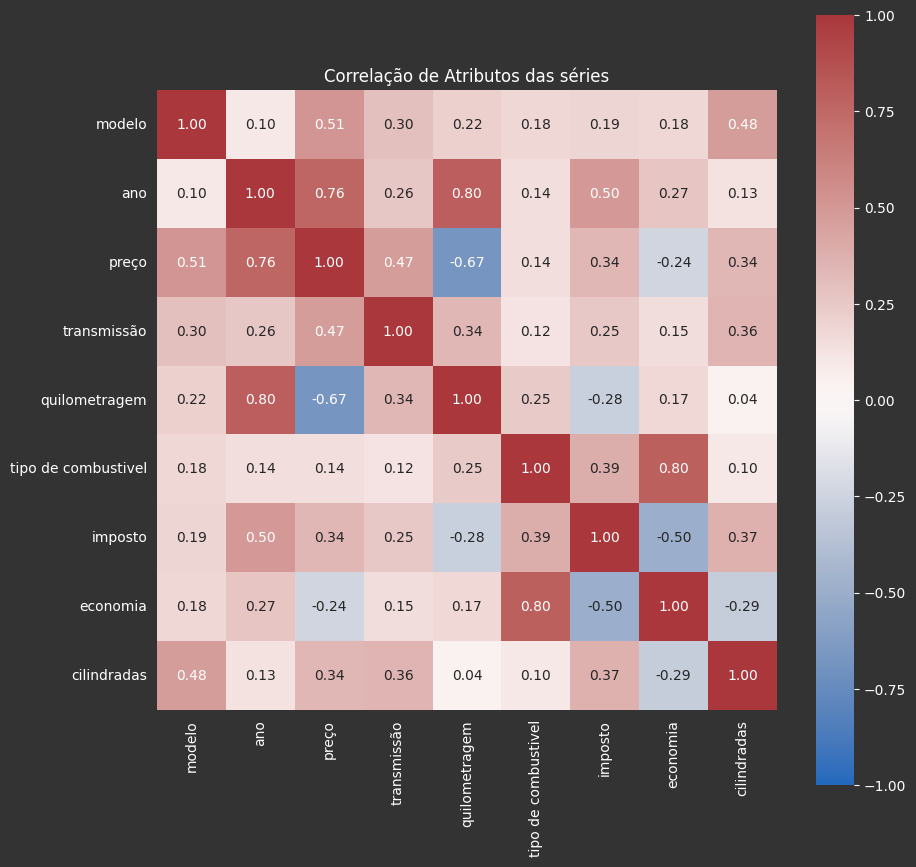


=== CORRELAÇÃO MUITO FORTE ===
[0.801] ano <--> quilometragem

=== CORRELAÇÃO FORTE ===
[0.795] tipo de combustivel <--> economia
[0.764] ano <--> preço
[0.672] preço <--> quilometragem

=== CORRELAÇÃO MODERADO ===
[0.511] modelo <--> preço
[0.500] imposto <--> economia
[0.499] ano <--> imposto
[0.475] modelo <--> cilindradas
[0.472] preço <--> transmissão

=== CORRELAÇÃO FRACO ===
[0.388] tipo de combustivel <--> imposto
[0.373] imposto <--> cilindradas
[0.359] transmissão <--> cilindradas
[0.343] preço <--> imposto
[0.341] preço <--> cilindradas
[0.336] transmissão <--> quilometragem
[0.298] modelo <--> transmissão
[0.294] economia <--> cilindradas
[0.277] quilometragem <--> imposto
[0.273] ano <--> economia
[0.265] ano <--> transmissão
[0.254] transmissão <--> imposto
[0.248] quilometragem <--> tipo de combustivel
[0.241] preço <--> economia
[0.218] modelo <--> quilometragem

=== CORRELAÇÃO MUITO FRACO ===
[0.195] modelo <--> imposto
[0.184] modelo <--> economia
[0.183] modelo <-->

In [9]:
# Colunas categóricas
categorical_columns = ['modelo', 'ano', 'transmissão', 'tipo de combustivel']

# A função já calcula e plota automaticamente
result= associations(
    df_series,
    nominal_columns=categorical_columns,
    compute_only=False, # Gera o gráfico
    cmap='vlag',    # Mapa de cores 
    figsize=(10, 10), 
    title="Correlação de Atributos das séries"
)

# Também recuperamos os valores numéricos
corr_matrix = result['corr']

# Transforma em valores absolutos (valores muito
# negativos indicam correlação inversamente proporcional)
corr_abs = corr_matrix.abs()

# Máscara para evitar repetição 
mask = np.triu(np.ones_like(corr_abs, dtype=bool), k=1)

# Transforma a matriz em uma lista de pares (coluna1, coluna2, valor)
corr_pairs = corr_abs.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation_Value']

# Define as fronteiras e os títulos
bins = [0.0, 0.20, 0.40, 0.60, 0.80, 1.0]
labels = ['Muito Fraco', 'Fraco', 'Moderado', 'Forte', 'Muito Forte']

# Aplica as fronteiras e títulos
corr_pairs['Strength'] = pd.cut(
    corr_pairs['Correlation_Value'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True 
)

# Ordena os dados 
corr_pairs = corr_pairs.sort_values(by='Correlation_Value', ascending=False)

# Lista corrigida para usar as mesmas strings da variável 'labels' (ordem decrescente)
categories_to_print = ['Muito Forte', 'Forte', 'Moderado', 'Fraco', 'Muito Fraco']

for category in categories_to_print:
    print(f"\n=== CORRELAÇÃO {category.upper()} ===")
    
    # Filtra a categoria atual
    category_data = corr_pairs[corr_pairs['Strength'] == category]
    
    # Se a categoria não possui pares, deixa uma mensagem
    if category_data.empty:
        print("Não há pares nessa categoria.")
        continue
        
    for _, row in category_data.iterrows():
        feat1 = row['Feature_1']
        feat2 = row['Feature_2']
        val = row['Correlation_Value']
        print(f"[{val:.3f}] {feat1} <--> {feat2}")

### **Boxplots:**

#### **Gráficos de caixa dos modelos**

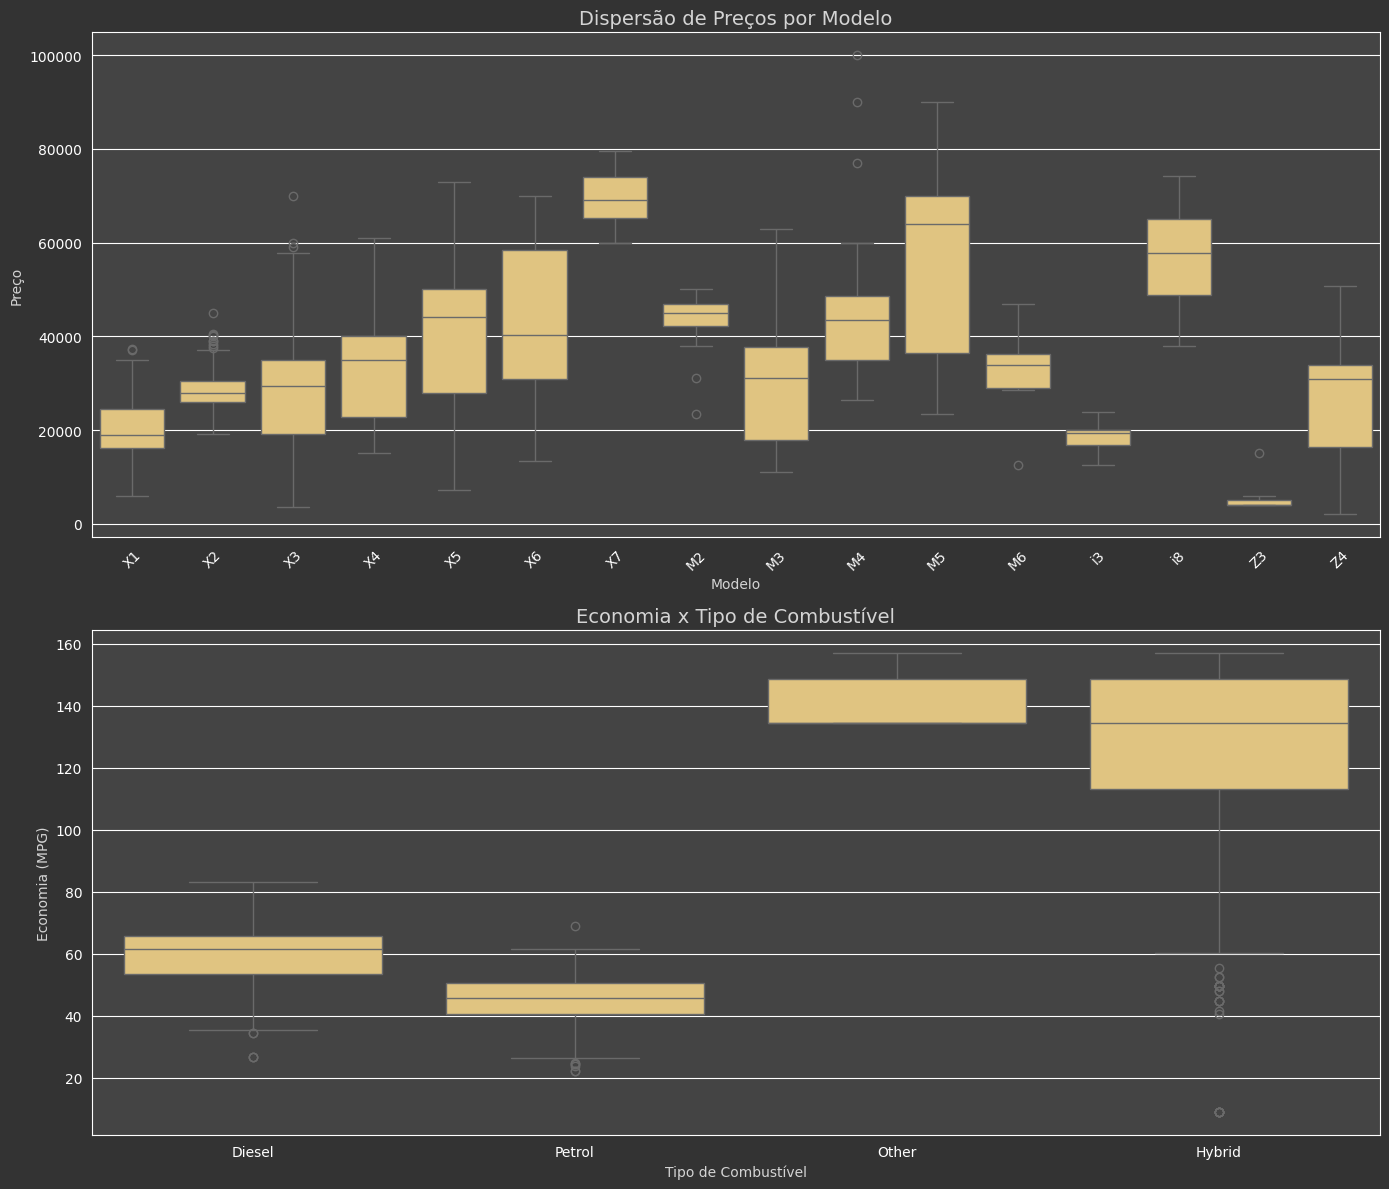

In [10]:
# Cria uma figura com espaço pra 2 gráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Define a ordem 
model_order = [
    'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 
    'M2', 'M3', 'M4', 'M5', 'M6', 
    'i3', 'i8', 
    'Z3', 'Z4'
]

# Preço x Modelo
sns.boxplot(
    data=df_models,
    x='modelo',
    y='preço',
    order=model_order,
    color="#f0ca71",
    ax=axes[0]
)
axes[0].set_title('Dispersão de Preços por Modelo', color='#D4D4D4', fontsize=14)
axes[0].set_ylabel('Preço', color='#d4d4d4')
axes[0].set_xlabel('Modelo', color='#d4d4d4')

# Rotaciona os nomes dos modelos em 45 
axes[0].tick_params(axis='x', rotation=45) 

# Economia x Combustível 
sns.boxplot(
    data=df_series,
    x='tipo de combustivel',
    y='economia',
    color="#f0ca71",
    ax=axes[1]
)
axes[1].set_title('Economia x Tipo de Combustível', color='#d4d4d4', fontsize=14)
axes[1].set_ylabel('Economia (MPG)', color='#d4d4d4')
axes[1].set_xlabel('Tipo de Combustível', color='#d4d4d4')

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

#### **Gráficos de caixa das séries**

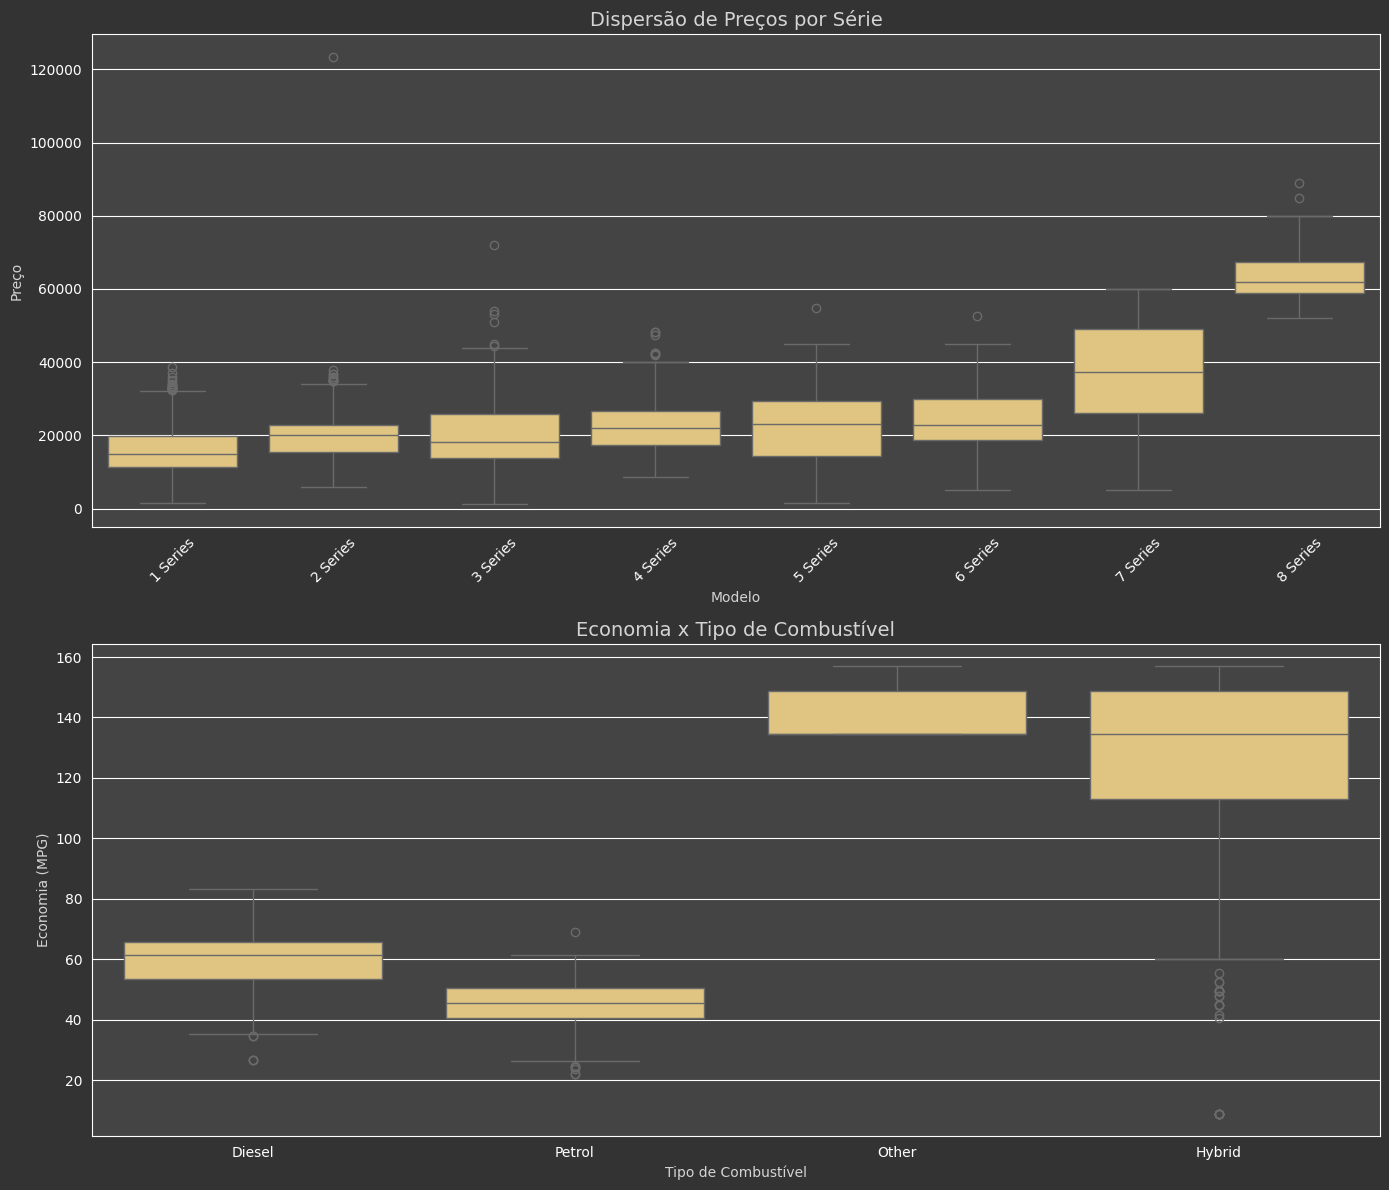

In [11]:
# Cria uma figura com espaço pra 2 gráficos
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12))

# Define a ordem 
series_order = [
    '1 Series', '2 Series', '3 Series', '4 Series',
    '5 Series', '6 Series', '7 Series', '8 Series'
]

# Preço x Modelo
sns.boxplot(
    data=df_series,
    x='modelo',
    y='preço',
    color="#f0ca71",
    order=series_order,
    ax=axes[0]
)

axes[0].set_title('Dispersão de Preços por Série', color='#d4d4d4', fontsize=14)
axes[0].set_ylabel('Preço', color='#d4d4d4')
axes[0].set_xlabel('Modelo', color='#d4d4d4')

# Rotaciona os nomes dos modelos em 45 
axes[0].tick_params(axis='x', rotation=45) 

# Economia x Combustível 
sns.boxplot(
    data=df_series,
    x='tipo de combustivel',
    y='economia',
    color="#f0ca71",
    ax=axes[1]
)
axes[1].set_title('Economia x Tipo de Combustível', color='#d4d4d4', fontsize=14)
axes[1].set_ylabel('Economia (MPG)', color='#d4d4d4')
axes[1].set_xlabel('Tipo de Combustível', color='#d4d4d4')

# Ajusta o espaçamento
plt.tight_layout()
plt.show()

### **Scatterplots:**

#### **Scatterplots de depreciação**

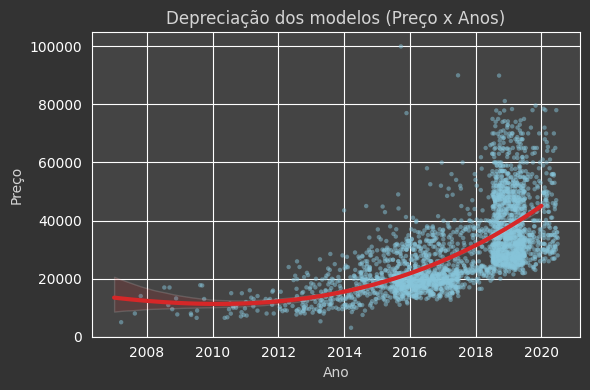

In [12]:
# Mantém apenas a grande maioria dos dados 
# para melhor visualização (trimming)
df_models_filtered = df_models[
    (df_models['ano'] >= 2007) & 
    (df_models['quilometragem'] <= 125000)
]

# Cria a figura 
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Ano 
sns.regplot(
    data=df_models_filtered,
    x='ano',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': "#87c5da"},
    line_kws={'color': '#d62728', 'linewidth': 3}, 
    order=3,            
    x_jitter=0.5
)
axes.set_title('Depreciação dos modelos (Preço x Anos)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

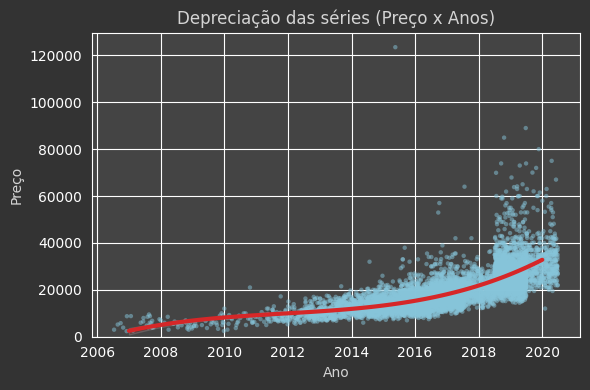

In [13]:
# Mantém apenas a grande maioria dos dados 
# para melhor visualização (trimming)
df_series_filtered = df_series[
    (df_series['ano'] >= 2007) & 
    (df_series['quilometragem'] <= 125000)
]

# Cria a figura 
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Ano 
sns.regplot(
    data=df_series_filtered,
    x='ano',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': "#87c5da"},
    line_kws={'color': '#d62728', 'linewidth': 3}, 
    order=3,            
    x_jitter=0.5
)
axes.set_title('Depreciação das séries (Preço x Anos)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

#### **Scatterplots de uso**

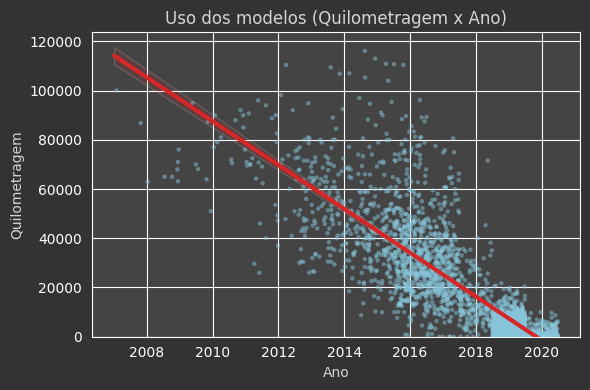

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Quilometragem x Ano 
sns.regplot(
    data=df_models_filtered,
    x='ano',
    y='quilometragem',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    x_jitter=0.5,
    ax=axes
)
axes.set_title('Uso dos modelos (Quilometragem x Ano)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Quilometragem', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


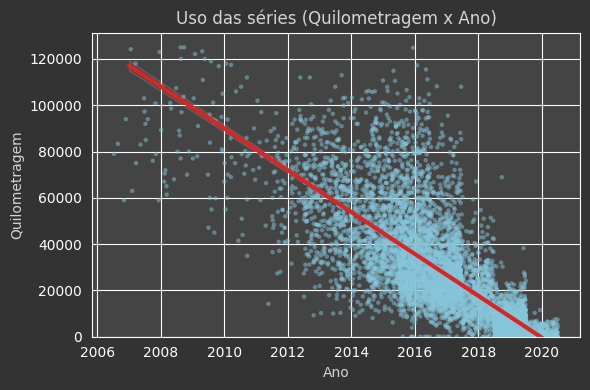

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Quilometragem x Ano 
sns.regplot(
    data=df_series_filtered,
    x='ano',
    y='quilometragem',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    x_jitter=0.5,
    ax=axes
)
axes.set_title('Uso das séries (Quilometragem x Ano)', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Quilometragem', color='#d4d4d4')
axes.set_xlabel('Ano', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


#### **Scatterplots de Preço por Quilometragem**

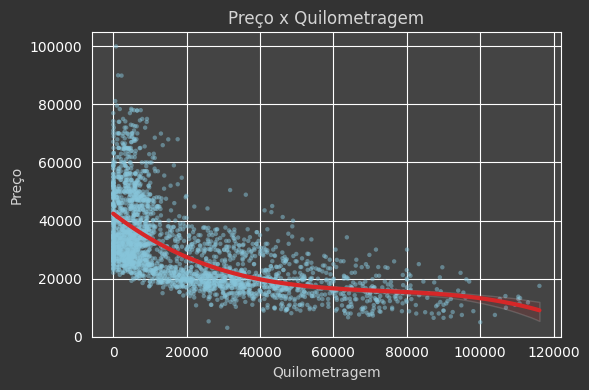

In [16]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Quilometragem
sns.regplot(
    data=df_models_filtered,
    x='quilometragem',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    order=3,            
    ax=axes
)
axes.set_title('Preço x Quilometragem', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Quilometragem', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

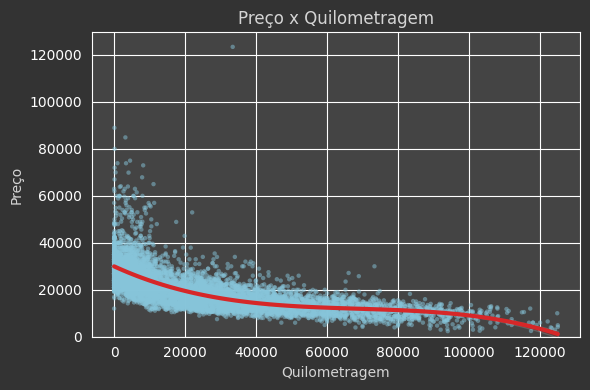

In [17]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))

# Preço x Quilometragem
sns.regplot(
    data=df_series_filtered,
    x='quilometragem',
    y='preço',
    scatter_kws={'alpha': 0.5, 's': 10, 'edgecolor': 'none', 'color': '#87c5da'},
    line_kws={'color': '#d62728', 'linewidth': 3},
    order=3,            
    ax=axes
)
axes.set_title('Preço x Quilometragem', color='#d4d4d4', fontsize=12)
axes.set_ylabel('Preço', color='#d4d4d4')
axes.set_xlabel('Quilometragem', color='#d4d4d4')
axes.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### **Realizando um teste de hipóteses:**
#### **Queremos saber se, estatísticamente, é mais econômico um carro à diesel ou à gasolina.**
#### Para isso, vamos calcular a eficiência de cada motor e depois comparar isso com os preços do diesel e da gasolina

#### **Primeiro passo: balancear as classes**
Vamos contar quantos exemplos de cada um existem nos dados e balancear pela menor quantidade. Para isso, vamos sortear o mesmo exato número dentro do maior grupo

In [18]:
# Separa os dois grupos
df_diesel = df_series[df_series['tipo de combustivel'] == 'Diesel']
df_petrol = df_series[df_series['tipo de combustivel'] == 'Petrol']

# Descobre a quantidade exata de cada classe
qtt_petrol = len(df_petrol) 
qtt_diesel = len(df_diesel) 

print(f"Quantidade de exemplos com gasolina: {qtt_petrol}")
print(f"Quantidade de exemplos com diesel: {qtt_diesel}")

# Pega a menor quantidade 
minor_qtt = min(qtt_diesel, qtt_petrol)

# Sorteia aleatoriamente a mesma quantidade de ambos os grupos
df_diesel_balanced = df_diesel.sample(n=minor_qtt, random_state=42)
df_petrol_balanced = df_petrol.sample(n=minor_qtt, random_state=42)

# Junta os dois pedaços 
df_balanced = pd.concat([df_diesel_balanced, df_petrol_balanced])

# Embaralha a ordem dos exemplos
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Novo total de gasolina: {len(df_balanced[df_balanced['tipo de combustivel'] == 'Petrol'])}")
print(f"Novo total de diesel:   {len(df_balanced[df_balanced['tipo de combustivel'] == 'Diesel'])}")
print(f"Total de linhas na base de estudos: {len(df_balanced)}")

Quantidade de exemplos com gasolina: 2613
Quantidade de exemplos com diesel: 5086
Novo total de gasolina: 2613
Novo total de diesel:   2613
Total de linhas na base de estudos: 5226


#### **Próximo passo: plotar o gráfico de distribuição**

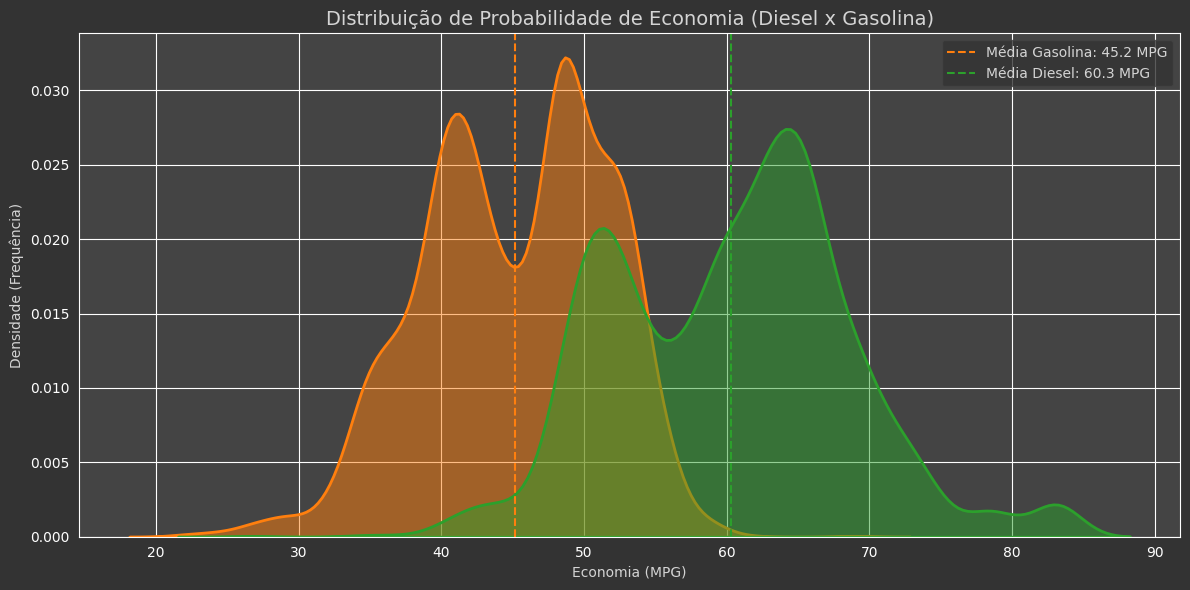

In [19]:
plt.figure(figsize=(12, 6))

# Gráfico de densidade
sns.kdeplot(
    data=df_balanced, 
    x='economia', 
    hue='tipo de combustivel', 
    fill=True,        
    palette={'Petrol': '#ff7f0e', 'Diesel': '#2ca02c'}, 
    alpha=0.5,           
    linewidth=2
)

# Títulos 
plt.title('Distribuição de Probabilidade de Economia (Diesel x Gasolina)', color='#d4d4d4', fontsize=14)
plt.xlabel('Economia (MPG)', color='#d4d4d4')
plt.ylabel('Densidade (Frequência)', color='#d4d4d4')

# Calcula as médias 
mean_petrol = df_balanced[df_balanced['tipo de combustivel'] == 'Petrol']['economia'].mean()
mean_diesel = df_balanced[df_balanced['tipo de combustivel'] == 'Diesel']['economia'].mean()

# Desenha as linhas das médias
plt.axvline(mean_petrol, color='#ff7f0e', linestyle='--', label=f'Média Gasolina: {mean_petrol:.1f} MPG')
plt.axvline(mean_diesel, color='#2ca02c', linestyle='--', label=f'Média Diesel: {mean_diesel:.1f} MPG')

# Ajustando a legenda para o fundo escuro
plt.legend(facecolor='#333333', edgecolor='#444', labelcolor='#d4d4d4')
plt.tight_layout()
plt.show()

#### **É possível ver que os dados não seguem a normalidade**, o que é esperado para dados reais. Sendo assim, **vamos realizar o teste U de Mann-Whitney**, que é não-paramétrico.

Matematicamente, ele faz: qual é a probabilidade de um carro a Diesel, escolhido ao acaso, ser mais econômico do que um carro a Gasolina, também escolhido ao acaso? 
Para isso, ele junta todos os carros em uma grande fila e os ranqueia

In [20]:
# Isola as variáveis
economia_diesel = df_balanced[df_balanced['tipo de combustivel'] == 'Diesel']['economia']
economia_gasolina = df_balanced[df_balanced['tipo de combustivel'] == 'Petrol']['economia']

# Executa o Teste U de Mann-Whitney
u_stat, p_valor = stats.mannwhitneyu(economia_diesel, economia_gasolina, alternative='greater')

# Imprime os resultados 
print("Resultado do teste U de Mann-Whitney")
print(f"Estatística U: {u_stat}")
print(f"P-Valor: {p_valor}")

# Nível de confiança de 95%
significance = 0.05 

print("\nConclusão Estatística:")
if p_valor < significance:
    print("Rejeitamos a Hipótese Nula (H0)")
    print("Está provado com significância estatística que os motores a Diesel são mais eficientes que os a Gasolina")
else:
    print("Falhamos em rejeitar a Hipótese Nula (H0)")
    print("A diferença visual pode ser obra do acaso. Não podemos afirmar que motores a Diesel são superior")

Resultado do teste U de Mann-Whitney
Estatística U: 6313299.5
P-Valor: 0.0

Conclusão Estatística:
Rejeitamos a Hipótese Nula (H0)
Está provado com significância estatística que os motores a Diesel são mais eficientes que os a Gasolina


#### Para finalizar, vamos usar os dados de preço por galão dos combustíveis e calcular qual deles é mais vantajoso

In [21]:
# Calcula a idade do carro (Data da coleta: 2020)
df_balanced['idade'] = 2020 - df_balanced['ano']

# Se o carro é de 2020 (idade = 0), arredonda para 1 ano de uso
df_balanced['idade'] = df_balanced['idade'].replace(0, 1)

# Calcula quantas milhas cada carro rodou por ano
df_balanced['milhas_por_ano'] = df_balanced['quilometragem'] / df_balanced['idade']

# Descobrindo a média real do mercado 
anual_miles = df_balanced['milhas_por_ano'].mean()

print(f"Os donos de BMW rodam em média {anual_miles:,.0f} milhas por ano\n")

# Preços por galão
petrol_price = 6.25
diesel_price = 6.86 

# Eficiências extraídas do teste
mpg_petrol = df_balanced[df_balanced['tipo de combustivel'] == 'Petrol']['economia'].mean()
mpg_diesel = df_balanced[df_balanced['tipo de combustivel'] == 'Diesel']['economia'].mean()

# Fórmula de custo
petrol_anual_cost = (anual_miles / mpg_petrol) * petrol_price
diesel_anual_cost = (anual_miles / mpg_diesel) * diesel_price
dif = petrol_anual_cost - diesel_anual_cost

print(f"Eficiência da gasolina: {mpg_petrol:.1f} MPG")
print(f"Eficiência do diesel: {mpg_diesel:.1f} MPG")

if dif > 0:
    print(f"O diesel é mais vantajoso")
    print(f"Economia anual para o cliente: {dif:,.2f}")
elif dif< 0:
    print(f"A gasolina é mais vantajosa")
    print(f"Economia anual para o cliente: {abs(dif):,.2f}")

Os donos de BMW rodam em média 7,394 milhas por ano

Eficiência da gasolina: 45.2 MPG
Eficiência do diesel: 60.3 MPG
O diesel é mais vantajoso
Economia anual para o cliente: 182.45


# Apresentação do Eixo 2

SUGESTÕES PARA EIXO 2

- Tratamento de Dados e Limpeza:

Identificação e tratamento de outliers em variáveis críticas como preço e quilometragem (ex: uso de Z-score ou IQR).

Verificação e preenchimento de dados faltantes (imputação pela média/mediana ou remoção estratégica).

- Codificação de Variáveis Categóricas (Encoding):

Target Encoding: Substituir os nomes dos modelos pela média de preço correspondente, facilitando a regressão.

One-Hot Encoding: Criar colunas binárias para variáveis com poucas categorias, como tipo de transmissão e combustível.

- Engenharia de Atributos (Feature Engineering):

Idade do Veículo: Criar a variável idade = ano_atual - ano_modelo.

Intensidade de Uso: Calcular km_por_ano = quilometragem / idade.

Rácios de Eficiência: Criar a relação preco_por_cv (preço por cavalo de potência) ou imposto_por_cilindrada.

Discretização (Binning): Categorizar a quilometragem em faixas (ex: "Seminovo", "Uso Moderado", "Alta Rodagem").

- Normalização e Padronização:

Aplicação de StandardScaler ou MinMaxScaler para garantir que variáveis em escalas diferentes (ex: quilometragem vs. cilindrada) tenham o mesmo peso no modelo.

- Redução de Dimensionalidade:

PCA (Análise de Componentes Principais): Reduzir a complexidade do dataset e eliminar ruído visualizando o agrupamento dos modelos.

Seleção de Variáveis: Identificar e manter apenas as características com maior correlação com o preço de revenda.

- Modelagem em Grafos (Abordagem Avançada):

Criar uma rede onde cada carro é um nó e as arestas conectam veículos com especificações técnicas idênticas (mesma série e motorização), visando análise de clusters.

## Imports

## tratamento de Dados e limpeza

# Modelagem em Grafos

In [22]:
import pandas as pd
import networkx as nx
from pyvis.network import Network
from IPython.display import display, HTML

# 1. Preparação (Garantindo que temos a coluna de ID)
coluna_identificadora = 'modelo_encoded' if 'modelo_encoded' in df.columns else df.columns[0]
df['id_especificacao'] = df[coluna_identificadora].astype(str) + "_" + df['cilindradas'].astype(str)

df_grafo = df.head(500).copy()
G = nx.Graph()

# 2. Adicionando os Nós (com informações ricas para o Hover/Mouse)
for idx, row in df_grafo.iterrows():
    # O PyVis usa a propriedade 'title' para mostrar o balão flutuante.
    # Usamos <br> para quebrar a linha no balão (já que ele usa HTML por trás)
    info_texto = (
        f"<b>ID/Modelo:</b> {row[coluna_identificadora]}<br>"
        f"<b>Preço:</b> R$ {row['preço']:,.2f}<br>"
        f"<b>Cilindradas:</b> {row['cilindradas']}<br>"
        f"<b>Ano:</b> {row['ano']}<br>"
        f"<b>Km:</b> {row['quilometragem']} km"
    )

    # Adicionamos o nó. 'value' muda o tamanho baseado no preço. 'group' muda a cor.
    G.add_node(idx,
               title=info_texto,
               value=row['preço'],
               group=row['id_especificacao'])

# 3. Adicionando as Arestas (Conexões)
for spec_id, group in df_grafo.groupby('id_especificacao'):
    indices = group.index.tolist()
    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):
            G.add_edge(indices[i], indices[j])

# 4. Magia Interativa (Configurando o PyVis)
# notebook=True garante que ele vai renderizar na sua tela
net = Network(height='600px', width='100%', bgcolor='#222222', font_color='white', notebook=True)

# Importa o grafo do NetworkX para o PyVis
net.from_nx(G)

# Adiciona botões de física (opcional, mas muito legal para organizar o grafo)
# net.show_buttons(filter_=['physics'])

# 5. Gerar e visualizar o arquivo
nome_arquivo = "rede_veiculos_interativa.html"

# tratando os outliers

In [23]:
print(df.isnull().sum())

modelo                 0
ano                    0
preço                  0
transmissão            0
quilometragem          0
tipo de combustivel    0
imposto                0
economia               0
cilindradas            0
id_especificacao       0
dtype: int64


In [24]:
# 2. Aplicação do Z-score
colunas_outliers = ['preço', 'quilometragem']
z_scores = np.abs(stats.zscore(df[colunas_outliers]))

# Filtro: Mantém apenas onde o Z-score é menor que 3 em todas as colunas selecionadas
df_zscore = df[(z_scores < 3).all(axis=1)].copy()

# Salvar o dataset
df_zscore.to_csv('bmw_zscore.csv', index=False)

print(f"Dataset Z-score criado com {len(df_zscore)} registros.")

Dataset Z-score criado com 10463 registros.


In [25]:
def filtrar_iqr(df, colunas):
    df_temp = df.copy()
    for col in colunas:
        Q1 = df_temp[col].quantile(0.25)
        Q3 = df_temp[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR
        df_temp = df_temp[(df_temp[col] >= limite_inf) & (df_temp[col] <= limite_sup)]
    return df_temp

# 2. Aplicação do filtro
df_iqr = filtrar_iqr(df, ['preço', 'quilometragem'])

# Salvar o dataset
df_iqr.to_csv('bmw_iqr.csv', index=False)

print(f"Dataset IQR criado com {len(df_iqr)} registros.")

Dataset IQR criado com 10063 registros.


--- COMPARAÇÃO DE MÉTODOS DE LIMPEZA ---
Total Original: 10781
Total Z-score:  10463 (Removeu 318)
Total IQR:      10063 (Removeu 718)


,Original,Z-score,IQR
Média de Preço,22733.408867,22068.482271,21392.035576


/tmp/ipykernel_7771/3016943155.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[0].boxplot([df['preço'], df_zscore['preço'], df_iqr['preço']], labels=['Original', 'Z-score', 'IQR'])
/tmp/ipykernel_7771/3016943155.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot([df['quilometragem'], df_zscore['quilometragem'], df_iqr['quilometragem']], labels=['Original', 'Z-score', 'IQR'])


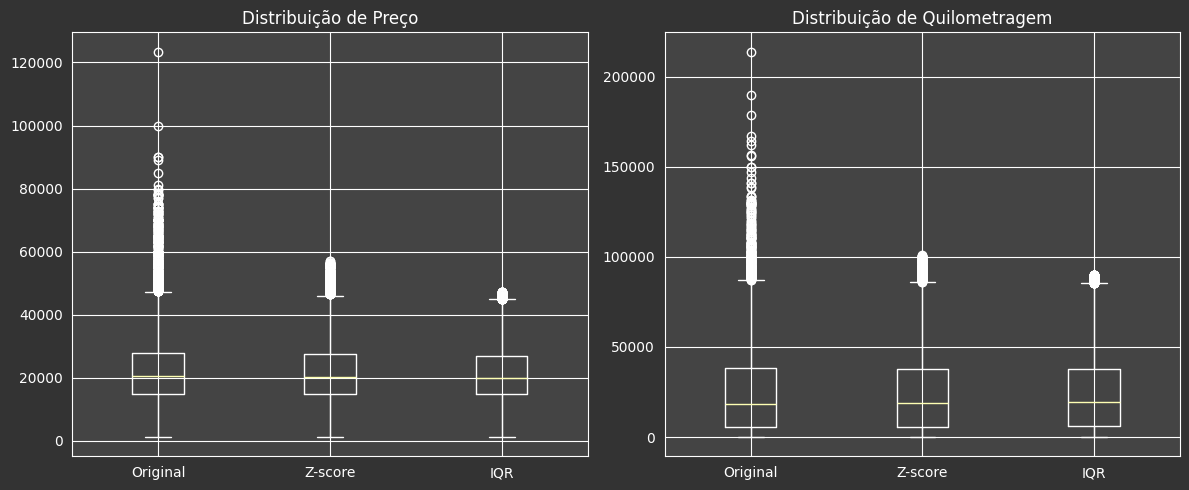

In [26]:
# Comparação de resultados
print("--- COMPARAÇÃO DE MÉTODOS DE LIMPEZA ---")
print(f"Total Original: {len(df)}")
print(f"Total Z-score:  {len(df_zscore)} (Removeu {len(df) - len(df_zscore)})")
print(f"Total IQR:      {len(df_iqr)} (Removeu {len(df) - len(df_iqr)})")

# Comparação das Médias
comp_preço = pd.DataFrame({
    'Original': df['preço'].mean(),
    'Z-score': df_zscore['preço'].mean(),
    'IQR': df_iqr['preço'].mean()
}, index=['Média de Preço'])

display(comp_preço)

# Visualização da distribuição
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].boxplot([df['preço'], df_zscore['preço'], df_iqr['preço']], labels=['Original', 'Z-score', 'IQR'])
ax[0].set_title('Distribuição de Preço')

ax[1].boxplot([df['quilometragem'], df_zscore['quilometragem'], df_iqr['quilometragem']], labels=['Original', 'Z-score', 'IQR'])
ax[1].set_title('Distribuição de Quilometragem')

plt.tight_layout()
plt.show()

df = df_iqr

Higienização de Texto: O str.strip() no modelo evita que o Python entenda " 3 Series" e "3 Series" como carros diferentes devido a um espaço invisível.

Tratamento de Outliers (IQR): Esta etapa é vital. Ela remove carros com preços irreais (como BMWs vendidas a 1 libra ou modelos de luxo com preços absurdamente fora da curva) e quilometragens extremas que enviesariam a média.

Filtro de Sanidade: Garante que o modelo de aprendizado de máquina não receba dados impossíveis (preço zero ou negativo).

# Codificação de Variáveis Categóricas (Encoding)

In [27]:
# 1. One-Hot Encoding para variáveis com poucas categorias
# Isso cria colunas separadas (0 ou 1) para cada tipo, sem criar uma hierarquia falsa.
df = pd.get_dummies(df, columns=['transmissão', 'tipo de combustivel'], prefix=['trans', 'comb'])

# 2. Target Encoding para a coluna 'modelo'
# Como existem muitos modelos, o One-Hot criaria colunas demais.
# O Target Encoding substitui o nome do modelo pela média de preço dele.
media_precos_modelo = df.groupby('modelo')['preço'].mean()
df['modelo_encoded'] = df['modelo'].map(media_precos_modelo)

colunas_texto = df.select_dtypes(include=['object', 'category']).columns
#df = df.drop(columns=colunas_texto)
# 3. Verificação do resultado
# 3. Verificação do resultado
print("Novas colunas após One-Hot Encoding:", [col for col in df.columns if 'trans_' in col or 'comb_' in col])

# Verificamos se 'modelo_encoded' existe. Se 'modelo' sumiu, imprimimos apenas a nova.
if 'modelo' in df.columns:
    print(f"Exemplo de Target Encoding: \n{df[['modelo', 'modelo_encoded']].iloc[0]}")
else:
    print(f"A coluna original 'modelo' foi removida. Valor da média na primeira linha: {df['modelo_encoded'].iloc[0]}")

display(df.head())

Novas colunas após One-Hot Encoding: ['trans_Automatic', 'trans_Manual', 'trans_Semi-Auto', 'comb_Diesel', 'comb_Electric', 'comb_Hybrid', 'comb_Other', 'comb_Petrol']
Exemplo de Target Encoding: 
modelo                5 Series
modelo_encoded    23047.209073
Name: 0, dtype: object


/tmp/ipykernel_7771/3356796657.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include=['object', 'category']).columns


,modelo,ano,preço,quilometragem,imposto,economia,cilindradas,id_especificacao,trans_Automatic,trans_Manual,trans_Semi-Auto,comb_Diesel,comb_Electric,comb_Hybrid,comb_Other,comb_Petrol,modelo_encoded
0,5 Series,2014,11200,67068,125,57.6,2.0,5 Series_2.0,True,False,False,True,False,False,False,False,23047.209073
1,6 Series,2018,27000,14827,145,42.8,2.0,6 Series_2.0,True,False,False,False,False,False,False,True,24569.990385
2,5 Series,2016,16000,62794,160,51.4,3.0,5 Series_3.0,True,False,False,True,False,False,False,False,23047.209073
3,1 Series,2017,12750,26676,145,72.4,1.5,1 Series_1.5,True,False,False,True,False,False,False,False,15982.890496
4,7 Series,2014,14500,39554,160,50.4,3.0,7 Series_3.0,True,False,False,True,False,False,False,False,28951.776119


- One-Hot Encoding (Transmissão/Combustível): É ideal para categorias pequenas. Se usássemos números simples (0, 1, 2), o modelo poderia achar que a transmissão "2" é "maior" ou "melhor" que a "1", o que não é verdade. Criar colunas de 0 e 1 resolve isso.

- Target Encoding (Modelo): A BMW tem dezenas de modelos (Série 1, X5, M3, etc). Se criássemos uma coluna para cada um, o dataset ficaria gigante e esparso (muitos zeros). Ao usar a média do preço, "avisamos" ao modelo quais nomes de carros costumam ser mais caros ou mais baratos de forma direta.

#  Engenharia de Atributos (Feature Engineering)

In [28]:
import numpy as np
import pandas as pd

# ==========================================
# ENGENHARIA DE ATRIBUTOS (FEATURE ENGINEERING)
# ==========================================

# 1. Alinhamento Temporal: Descobrir o ano mais recente no dataset
ano_referencia = df['ano'].max()
print(f"O ano base considerado para os cálculos da idade será: {ano_referencia}")

# 2. Idade do Veículo
# Usamos np.maximum(1, ...) para garantir que carros do mesmo ano da recolha
# tenham pelo menos "1" ano de vida útil matemático, evitando divisão por zero.
df['idade'] = np.maximum(1, ano_referencia - df['ano'])

# 3. Intensidade de Uso (Quilometragem por ano)
df['km_por_ano'] = df['quilometragem'] / df['idade']

# 4. Rácios de Eficiência e Valor
# a) Imposto por Cilindrada (usando np.where para evitar divisão por zero se cilindrada for 0)
df['imposto_por_cilindrada'] = np.where(
    df['cilindradas'] > 0,
    df['imposto'] / df['cilindradas'],
    0
)

# b) Preço por Idade (Proxy de Desvalorização)
df['preco_por_idade'] = df['preço'] / df['idade']

# 5. Discretização (Binning) da Quilometragem
limites = [-1, 30000, 80000, np.inf]
# Nomes sem espaços para evitar erros futuros em modelos ou gráficos
categorias = ['Seminovo', 'Moderado', 'Alta_Rodagem']

df['categoria_km'] = pd.cut(df['quilometragem'], bins=limites, labels=categorias)

# 6. One-Hot Encoding da nova categoria (Transformar de volta em números)
# Gera as colunas: uso_Seminovo, uso_Moderado, uso_Alta_Rodagem
df = pd.get_dummies(df, columns=['categoria_km'], prefix='uso')

# ==========================================
# VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
colunas_visualizar = [
    'preço', 'ano', 'idade', 'quilometragem', 'km_por_ano',
    'preco_por_idade', 'imposto_por_cilindrada',
    'uso_Seminovo', 'uso_Moderado', 'uso_Alta_Rodagem'
]

print("\nAmostra das novas variáveis criadas:")

pd.set_option('display.max_columns', None)

# Agora o seu comando mostrará tudo
display(df.head(10))

O ano base considerado para os cálculos da idade será: 2020

Amostra das novas variáveis criadas:


,modelo,ano,preço,quilometragem,imposto,economia,cilindradas,id_especificacao,trans_Automatic,trans_Manual,trans_Semi-Auto,comb_Diesel,comb_Electric,comb_Hybrid,comb_Other,comb_Petrol,modelo_encoded,idade,km_por_ano,imposto_por_cilindrada,preco_por_idade,uso_Seminovo,uso_Moderado,uso_Alta_Rodagem
0,5 Series,2014,11200,67068,125,57.6,2.0,5 Series_2.0,True,False,False,True,False,False,False,False,23047.209073,6,11178.000000,62.500000,1866.666667,False,True,False
1,6 Series,2018,27000,14827,145,42.8,2.0,6 Series_2.0,True,False,False,False,False,False,False,True,24569.990385,2,7413.500000,72.500000,13500.000000,True,False,False
2,5 Series,2016,16000,62794,160,51.4,3.0,5 Series_3.0,True,False,False,True,False,False,False,False,23047.209073,4,15698.500000,53.333333,4000.000000,False,True,False
3,1 Series,2017,12750,26676,145,72.4,1.5,1 Series_1.5,True,False,False,True,False,False,False,False,15982.890496,3,8892.000000,96.666667,4250.000000,True,False,False
4,7 Series,2014,14500,39554,160,50.4,3.0,7 Series_3.0,True,False,False,True,False,False,False,False,28951.776119,6,6592.333333,53.333333,2416.666667,False,True,False
5,5 Series,2016,14900,35309,125,60.1,2.0,5 Series_2.0,True,False,False,True,False,False,False,False,23047.209073,4,8827.250000,62.500000,3725.000000,False,True,False
6,5 Series,2017,16000,38538,125,60.1,2.0,5 Series_2.0,True,False,False,True,False,False,False,False,23047.209073,3,12846.000000,62.500000,5333.333333,False,True,False
7,2 Series,2018,16250,10401,145,52.3,1.5,2 Series_1.5,False,True,False,False,False,False,False,True,19533.148482,2,5200.500000,96.666667,8125.000000,True,False,False
8,4 Series,2017,14250,42668,30,62.8,2.0,4 Series_2.0,False,True,False,True,False,False,False,False,22588.376663,3,14222.666667,15.000000,4750.000000,False,True,False
9,5 Series,2016,14250,36099,20,68.9,2.0,5 Series_2.0,True,False,False,True,False,False,False,False,23047.209073,4,9024.750000,10.000000,3562.500000,False,True,False


# Normalização e Padronização

In [29]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Definir as colunas contínuas para a análise (não incluímos o Target 'preço')
colunas_para_pca = [
    'idade',
    'quilometragem',
    'imposto',
    'economia',
    'cilindradas',
    'km_por_ano',
    'imposto_por_cilindrada'
]


# 2. Criar uma cópia apenas com os dados numéricos contínuos
# Fazemos isso para não aplicar padronização nas colunas dummies (0 e 1)
df_numerico = df[colunas_para_pca].copy()

# 3. Inicializar e aplicar o Padronizador
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numerico)

# O output 'X_scaled' é uma matriz numpy. Seus dados estão prontos para o PCA.
print(f"Dados padronizados. Formato da matriz: {X_scaled.shape}")
print("Média de cada coluna (deve ser ~0):", np.mean(X_scaled, axis=0).round(2))
print("Desvio padrão de cada coluna (deve ser 1):", np.std(X_scaled, axis=0).round(2))

Dados padronizados. Formato da matriz: (10063, 7)
Média de cada coluna (deve ser ~0): [ 0. -0. -0. -0.  0. -0.  0.]
Desvio padrão de cada coluna (deve ser 1): [1. 1. 1. 1. 1. 1. 1.]


# redução de dimensionalidade

In [30]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Inicializar o PCA
# 'n_components=None' calcula todos os componentes possíveis (7 no nosso caso)
# para que possamos analisar quantos são necessários.
pca = PCA(n_components=None)

# 2. Treinar o PCA nos dados padronizados
X_pca = pca.fit_transform(X_scaled)

# 3. Análise da Variância Explicada (Validação Científica)
variancia_explicada_ratio = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada_ratio)

print("Análise de Variância Explicada por Componente:")
for i, ratio in enumerate(variancia_explicada_ratio):
    print(f"PC{i+1}: {ratio:.2%} (Acumulado: {variancia_acumulada[i]:.2%})")

# 4. Decisão de Quantos Componentes Manter
# Regra geral: Manter componentes que expliquem entre 80% a 95% da variância total.
# Olhando os acumulados acima, se PC1+PC2+PC3 explicarem >85%, mantemos n=3.
num_componentes_a_manter = 3  # Vamos assumir 3 para este exemplo, ajuste conforme necessário.

# 5. Criar o DataFrame final com os Componentes Principais
colunas_pca = [f'PCA_{i+1}' for i in range(num_componentes_a_manter)]
df_pca_final = pd.DataFrame(X_pca[:, :num_componentes_a_manter], columns=colunas_pca)

# 6. Juntar de volta com o resto do DataFrame (Preço e Dummies)
# Primeiro, removemos as colunas originais que foram usadas no PCA
df_restante = df.drop(columns=colunas_para_pca).reset_index(drop=True)
df_pca_completo = pd.concat([df_restante, df_pca_final], axis=1)

print("\n--- NOVO DATASET PRONTO PARA TREINAMENTO COM PCA ---")
print(f"Colunas originais removidas: {colunas_para_pca}")
print(f"Novas colunas adicionadas: {colunas_pca}")
display(df_pca_completo.head())

Análise de Variância Explicada por Componente:
PC1: 38.05% (Acumulado: 38.05%)
PC2: 25.88% (Acumulado: 63.93%)
PC3: 14.36% (Acumulado: 78.30%)
PC4: 10.91% (Acumulado: 89.20%)
PC5: 9.24% (Acumulado: 98.44%)
PC6: 0.94% (Acumulado: 99.39%)
PC7: 0.61% (Acumulado: 100.00%)

--- NOVO DATASET PRONTO PARA TREINAMENTO COM PCA ---
Colunas originais removidas: ['idade', 'quilometragem', 'imposto', 'economia', 'cilindradas', 'km_por_ano', 'imposto_por_cilindrada']
Novas colunas adicionadas: ['PCA_1', 'PCA_2', 'PCA_3']


,modelo,ano,preço,id_especificacao,trans_Automatic,trans_Manual,trans_Semi-Auto,comb_Diesel,comb_Electric,comb_Hybrid,comb_Other,comb_Petrol,modelo_encoded,preco_por_idade,uso_Seminovo,uso_Moderado,uso_Alta_Rodagem,PCA_1,PCA_2,PCA_3
0,5 Series,2014,11200,5 Series_2.0,True,False,False,True,False,False,False,False,23047.209073,1866.666667,False,True,False,1.794739,1.390200,-0.853631
1,6 Series,2018,27000,6 Series_2.0,True,False,False,False,False,False,False,True,24569.990385,13500.000000,True,False,False,-0.757235,-0.139652,-0.118895
2,5 Series,2016,16000,5 Series_3.0,True,False,False,True,False,False,False,False,23047.209073,4000.000000,False,True,False,1.355157,2.380330,0.433816
3,1 Series,2017,12750,1 Series_1.5,True,False,False,True,False,False,False,False,15982.890496,4250.000000,True,False,False,-0.238209,-0.289537,-1.777842
4,7 Series,2014,14500,7 Series_3.0,True,False,False,True,False,False,False,False,28951.776119,2416.666667,False,True,False,0.429280,1.845297,0.813879


uso do pca
- Ganho: O seu modelo pode treinar mais rápido e ser menos propenso a "decorar" os dados (overfitting), pois reduzimos a complexidade dos dados de entrada.

- Perda: Você perde a interpretabilidade. No dataset final (df_pca_completo), você não sabe mais o quanto a 'idade' afeta o preço. Você só sabe o quanto o 'PCA_1' afeta o preço, mas o 'PCA_1' é uma mistura matemática de idade, km e imposto.